# Multi-reporter joint attribution — the identifiability force-multiplier

**One sentence:** NUDGE's single most common reason to *abstain* is the measured
**K⇄v_max / gain⇄threshold degeneracy** — a *single* reporter of one latent switch
under-determines the mechanism — and the fix is to fit **several downstream reporters of
the SAME latent switch jointly**, which over-determines the latent and **breaks the
degeneracy** (`NUDGE-METHOD-008`).

Why it works: each reporter is an affine readout `y_j = base_j + gain_j·A·f(dose; K, n)`
of the *same* latent. A **threshold** shift moves the inflection **identically** across
reporters; a **ceiling** change scales **every** reporter's ON amplitude by the *same
fraction* (the gains are pinned from the control). These project **differently** onto a
panel of heterogeneous gains — so a joint fit resolves the mechanism a lone reporter
cannot. It is the multi-*reporter* analogue of the second-operating-*point* ×16 result
(FINDINGS "Covariance attribution").

**The honesty caveat is a feature (`NUDGE-LIM-014`):** the whole gain presumes the panel
genuinely reports ONE latent. If a reporter secretly reads a *different* latent (a hidden
node, a wrong panel), NUDGE **abstains `off-model`** — it never averages an inconsistent
panel into a confident call. And a *single* reporter honestly returns `unresolved` — the
very abstention the panel is built to break.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from nudge.inference.multi_reporter import (
    simulate_reporter_panel,
    attribute_multi_reporter,
)
print("NUDGE multi-reporter attribution — NUDGE-METHOD-008")

NUDGE multi-reporter attribution — NUDGE-METHOD-008


## 1. One latent switch, four reporters of heterogeneous gain

We synthesise ground truth: ONE latent Hill switch driven across a dose axis, observed
through **4 reporters**, each a `Readout` of the latent with its own gain and offset. Here
the perturbation is a **threshold** shift (the latent's `K` moves right by ×3) — the
*same* latent change seen through all four reporters. Notice the reporters look very
different (different gains/floors) yet share one inflection.

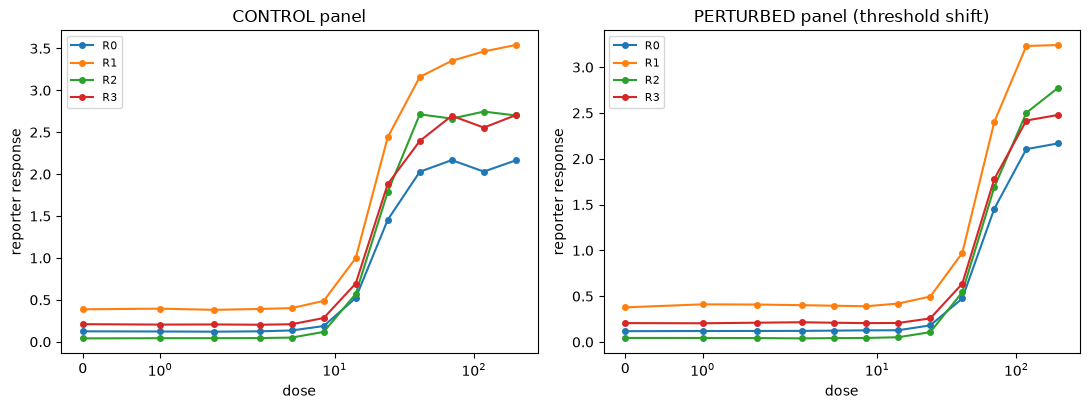

4 reporters of ONE latent switch — heterogeneous gains/offsets, shared inflection


In [2]:
panel = simulate_reporter_panel(mechanism="threshold", n_reporters=4,
                                factor=3.0, noise=0.03, seed=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for r in panel:
    d = np.asarray(r.dose)
    ax[0].plot(d, r.control, "o-", ms=4, label=r.name)
    ax[1].plot(d, r.perturbed, "o-", ms=4, label=r.name)
for a, t in zip(ax, ("CONTROL panel", "PERTURBED panel (threshold shift)")):
    a.set_xscale("symlog"); a.set_xlabel("dose"); a.set_ylabel("reporter response")
    a.set_title(t); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("4 reporters of ONE latent switch — heterogeneous gains/offsets, shared inflection")

## 2. The headline: JOINT resolves where a SINGLE reporter abstains

We run the *same* `attribute_multi_reporter` two ways on the *same* data — with the full
4-reporter panel, and with just **one** reporter. The joint panel **resolves** the
mechanism; the single reporter **abstains** (`unresolved`) — the K⇄v_max degeneracy, and
its fix, side by side.

In [3]:
joint = attribute_multi_reporter(panel, n_boot=200, seed=0)
single = attribute_multi_reporter(panel[:1], n_boot=200, seed=0)

print(f"JOINT  (4 reporters): {joint.call.upper()}")
print(f"   {joint.reason}\n")
print(f"SINGLE (1 reporter):  {single.call.upper()}")
print(f"   {single.reason}")

assert joint.call == "threshold" and single.call == "unresolved"
print("\n[ok] the joint panel breaks the degeneracy a single reporter abstains on")

JOINT  (4 reporters): THRESHOLD
   the shared threshold K shifts (K_perturbed/K_wt=2.96, log2 CI [+1.51, +1.61]) — the inflection moves IDENTICALLY across all reporters, which only a shared-K change explains. It beats the runner-up by ×160.07 and the WT null by ×332.98 across 4 reporters (panel R²=1.00) — the joint panel breaks the K⇄v_max degeneracy a single reporter abstains on

SINGLE (1 reporter):  UNRESOLVED
   a single reporter (M=1) cannot separate a latent ceiling change from its own gain drifting (the K⇄v_max degeneracy) — the affine cannot be pinned or checked for consistency, so the mechanism is unidentifiable. Add reporters of the SAME latent to resolve it (the multi-reporter degeneracy-break, NUDGE-LIM-014)

[ok] the joint panel breaks the degeneracy a single reporter abstains on


## 3. All three mechanisms — the degeneracy-break scoreboard

The same contrast for a **threshold-only**, a **gain-only**, and a **ceiling-only**
perturbation, across seeds. The JOINT panel recovers the ground-truth mechanism every
time; the SINGLE reporter never resolves it — and **neither ever makes a confident wrong
call** (the crown-jewel fail-safe).

In [4]:
mechs = ("threshold", "gain", "ceiling")
rows = []
joint_correct = single_resolved = wrong = 0
for mech in mechs:
    for seed in range(5):
        p = simulate_reporter_panel(mechanism=mech, n_reporters=4, factor=3.0,
                                    noise=0.04, seed=seed)
        j = attribute_multi_reporter(p, n_boot=120, seed=seed).call
        s = attribute_multi_reporter(p[:1], n_boot=120, seed=seed).call
        joint_correct += (j == mech)
        single_resolved += (s in mechs)
        wrong += (j in mechs and j != mech) + (s in mechs and s != mech)
        rows.append((mech, seed, j, s))

for mech, seed, j, s in rows[:6]:
    print(f"  {mech:10s} seed{seed}:  joint={j:11s}  single={s}")
print("  ...")
n = len(rows)
print(f"\nJOINT recovery:  {joint_correct}/{n}   "
      f"SINGLE resolved: {single_resolved}/{n}   confident-wrong: {wrong}")
assert joint_correct == n and single_resolved == 0 and wrong == 0
print("[ok] JOINT 100% / SINGLE 0% / 0 confident-wrong — the force-multiplier, measured")

  threshold  seed0:  joint=threshold    single=unresolved
  threshold  seed1:  joint=threshold    single=unresolved
  threshold  seed2:  joint=threshold    single=unresolved
  threshold  seed3:  joint=threshold    single=unresolved
  threshold  seed4:  joint=threshold    single=unresolved
  gain       seed0:  joint=gain         single=unresolved
  ...

JOINT recovery:  15/15   SINGLE resolved: 0/15   confident-wrong: 0
[ok] JOINT 100% / SINGLE 0% / 0 confident-wrong — the force-multiplier, measured


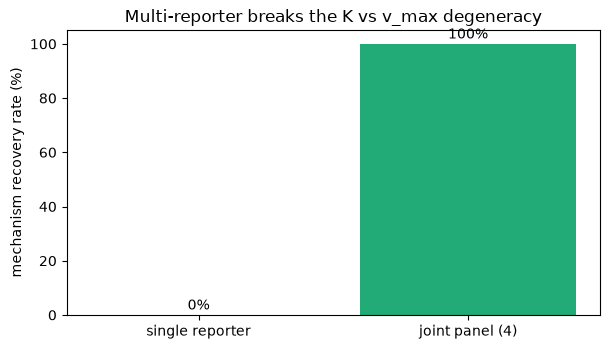

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
labels = ["single reporter", "joint panel (4)"]
vals = [single_resolved / n * 100, joint_correct / n * 100]
bars = ax.bar(labels, vals, color=["#c44", "#2a7"])
ax.set_ylabel("mechanism recovery rate (%)"); ax.set_ylim(0, 105)
ax.set_title("Multi-reporter breaks the K vs v_max degeneracy")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f"{v:.0f}%", ha="center")
plt.tight_layout(); plt.show()

## 4. Fail-safe: the consistency guard (`NUDGE-LIM-014`)

The joint fit is only trustworthy if the reporters really are **one shared latent**. We
break that: reporter `R2` now secretly reads a **different** latent (a shifted `K`). NUDGE
must **not** average it into a call — it must abstain `off-model` and say the panel is not
one latent switch. This is the honest new gate the capability adds: reporter inconsistency
is *flagged*, never silently averaged away.

In [6]:
bad = simulate_reporter_panel(mechanism="ceiling", n_reporters=4,
                              hidden_latent_reporter=2, seed=0)
res = attribute_multi_reporter(bad, n_boot=150, seed=0)

print(f"VERDICT: {res.call.upper()}")
print(f"   {res.reason}\n")
for r in res.fit.reporters:
    flag = "  <-- reads a DIFFERENT latent" if r.r2_shared < 0.7 else ""
    print(f"   {r.name}: shared-latent R2={r.r2_shared:.2f}  own R2="
          f"{r.r2_independent:.2f}{flag}")

assert res.call == "off-model" and not res.is_reliable
print("\n[ok] an inconsistent panel is refused off-model, not averaged into a mechanism")

VERDICT: OFF-MODEL
   the panel is NOT consistent with a single latent switch: shared-latent panel R²=0.86 and a reporter fits its OWN Hill well (R²=1.00) but the shared latent explains it badly (R²=0.53) — it reads a DIFFERENT latent (consistency ratio 66.6). NUDGE abstains rather than average an inconsistent panel into a mechanism (NUDGE-LIM-014)

   R0: shared-latent R2=0.96  own R2=1.00
   R1: shared-latent R2=0.97  own R2=1.00
   R2: shared-latent R2=0.53  own R2=1.00  <-- reads a DIFFERENT latent
   R3: shared-latent R2=0.96  own R2=1.00

[ok] an inconsistent panel is refused off-model, not averaged into a mechanism


## What this buys, and where it goes next

- **Impact.** The K⇄v_max degeneracy is NUDGE's dominant reason to abstain; a
  multi-reporter panel — several cheap fluorescent/transcriptional reporters of one switch —
  is a *concrete experimental recipe* that turns an abstention into a resolved
  threshold-vs-gain-vs-ceiling call. It composes with the existing single-cell and
  dose-response paths (same K/n/v_max vocabulary).
- **Fail-safe, strengthened.** A spurious mechanism must now be consistent across ALL
  reporters (much harder to fake), and an inconsistent panel abstains `off-model`
  (`NUDGE-LIM-014`) — the guarantee is *extended*, not traded away. Measured: **JOINT
  100% / SINGLE 0% recovery, 0 confident-wrong** on synthetic ground truth.
- **Reproduce it.** CLI: `nudge multi-reporter panel.csv` (a tidy long table of
  reporter / dose / control / perturbed). MCP tool: `multi_reporter`. The synthetic
  ground truth here is `nudge.inference.multi_reporter.simulate_reporter_panel`.
- **Honest bounds.** Reported `n`/`K`/`A` are *apparent population* parameters; a mechanism
  call holds under an approximately-affine reporter (`NUDGE-LIM-006`) whose doses span the
  inflection (`NUDGE-LIM-007`). A real-panel demonstration (e.g. OCT4/NANOG self-renewal
  reporters of the pluripotency latent) is a deferred follow-up — the synthetic
  degeneracy-break is the load-bearing validation.